<a href="https://colab.research.google.com/github/mariemshrief28-prog/Machine-Learning-projects/blob/main/Wine_Quality_ML_Vs_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.feature_selection import RFE
from imblearn.over_sampling import RandomOverSampler

In [ ]:
df=pd.read_csv('WineQT.csv')

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
x=df.drop(['quality', 'chlorides', 'fixed acidity'], axis=1)

In [ ]:
for cols in x.columns:

  q1=df[cols].quantile(.25)
  q3=df[cols].quantile(.75)

  iqr=q3-q1

  upper= q3 + 1.9 * iqr
  lower= q1 - 1.9 * iqr

  df[cols]=df[cols].loc[(df[cols]>lower)&(df[cols]<upper)]


In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
#x=df[['sulphates', 'alcohol', 'volatile acidity', 'citric acid', 'pH', 'total sulfur dioxide', 'density']]

In [ ]:
#x=df.drop('quality', axis=1)
y=df['quality']


In [ ]:
y.unique().sum()

np.int64(33)

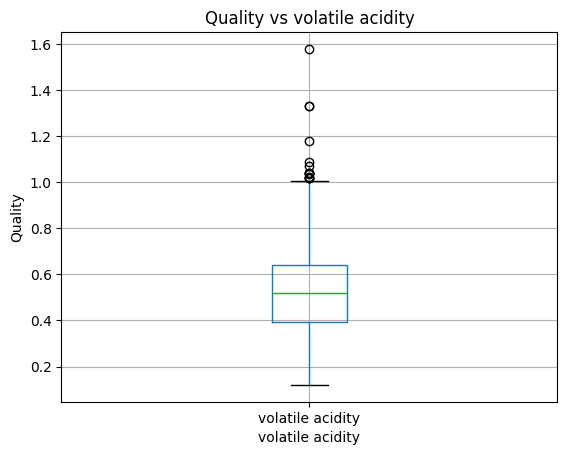

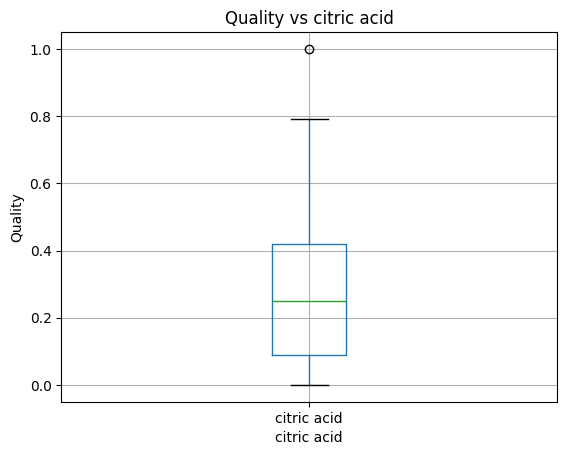

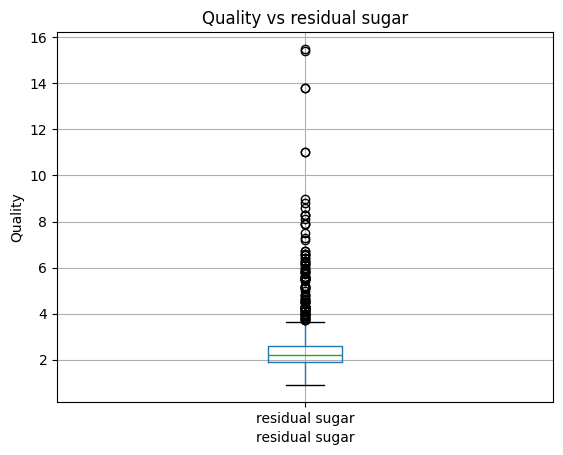

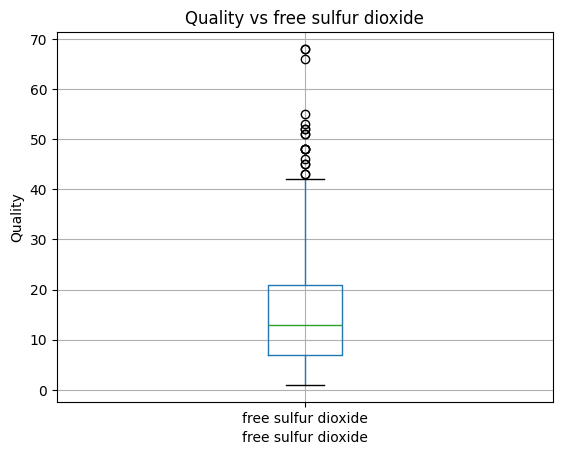

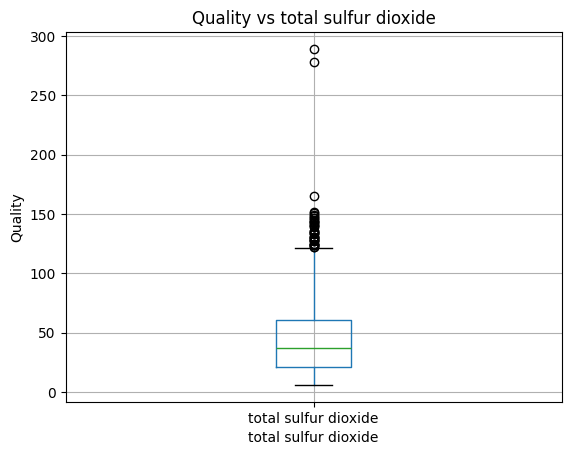

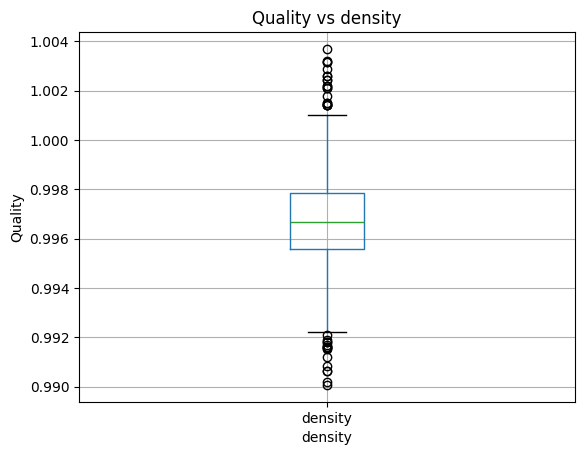

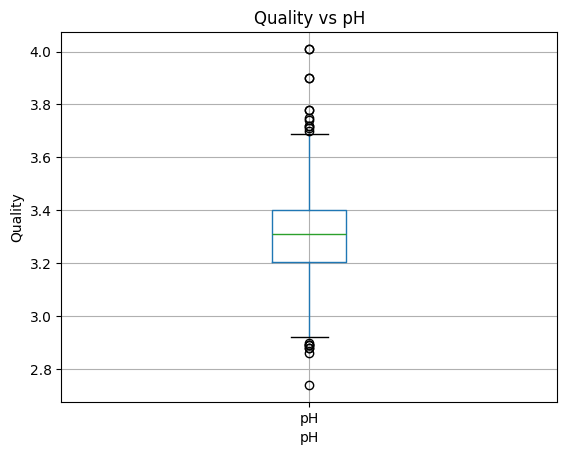

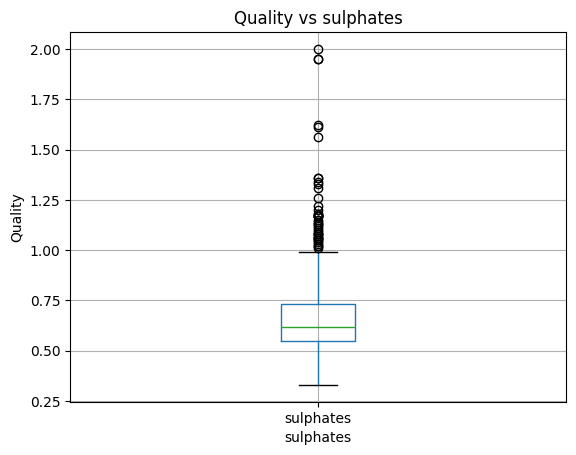

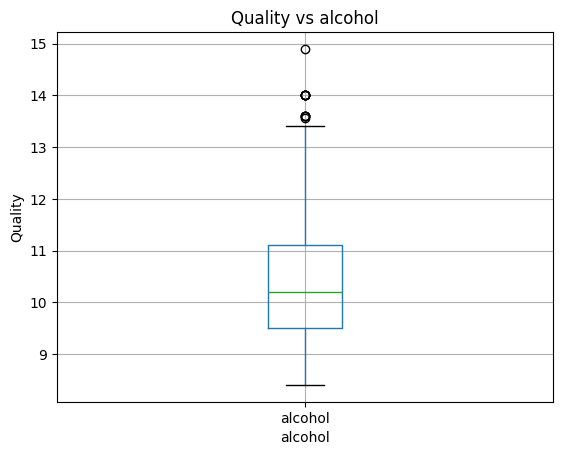

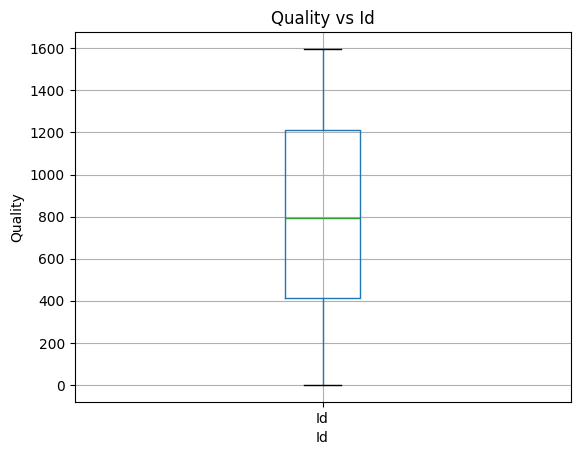

In [ ]:
for cols in x.columns:
  x.boxplot(column=cols)
  plt.xlabel(cols)
  plt.ylabel("Quality")
  plt.title(f"Quality vs {cols}")
  plt.show()

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   volatile acidity      1143 non-null   float64
 1   citric acid           1143 non-null   float64
 2   residual sugar        1143 non-null   float64
 3   free sulfur dioxide   1143 non-null   float64
 4   total sulfur dioxide  1143 non-null   float64
 5   density               1143 non-null   float64
 6   pH                    1143 non-null   float64
 7   sulphates             1143 non-null   float64
 8   alcohol               1143 non-null   float64
 9   Id                    1143 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 89.4 KB


In [ ]:
print(y.shape, x.shape)

(1143,) (1143, 10)


In [ ]:
for cols in x.columns:
  x[cols]= x[cols].fillna(x[cols].mean())

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   volatile acidity      1143 non-null   float64
 1   citric acid           1143 non-null   float64
 2   residual sugar        1143 non-null   float64
 3   free sulfur dioxide   1143 non-null   float64
 4   total sulfur dioxide  1143 non-null   float64
 5   density               1143 non-null   float64
 6   pH                    1143 non-null   float64
 7   sulphates             1143 non-null   float64
 8   alcohol               1143 non-null   float64
 9   Id                    1143 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 89.4 KB


In [ ]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.257372,0.673157,0.258134,0.107889,-0.169385,-0.123147,0.669148,-0.683808,0.215980,-0.092179,0.121970,-0.275826
volatile acidity,-0.257372,1.000000,-0.548184,0.011625,0.054200,0.003018,0.111332,-0.010166,0.213598,-0.358097,-0.216252,-0.399201,-0.005627
citric acid,0.673157,-0.548184,1.000000,0.187538,0.245312,-0.050752,-0.006223,0.375922,-0.543189,0.316980,0.100157,0.240821,-0.139011
residual sugar,0.258134,0.011625,0.187538,1.000000,0.052667,0.024285,0.119273,0.382142,-0.070597,0.026313,0.071029,0.012004,-0.132864
chlorides,0.107889,0.054200,0.245312,0.052667,1.000000,-0.032668,0.069097,0.183460,-0.253994,0.107103,-0.232348,-0.124085,-0.088099
free sulfur dioxide,-0.169385,0.003018,-0.050752,0.024285,-0.032668,1.000000,0.663525,-0.060610,0.078304,0.003967,-0.038271,-0.056358,0.076059
total sulfur dioxide,-0.123147,0.111332,-0.006223,0.119273,0.069097,0.663525,1.000000,0.107391,-0.013786,-0.056221,-0.221179,-0.206043,-0.113238
density,0.669148,-0.010166,0.375922,0.382142,0.183460,-0.060610,0.107391,1.000000,-0.317812,0.117771,-0.498298,-0.178769,-0.391385
pH,-0.683808,0.213598,-0.543189,-0.070597,-0.253994,0.078304,-0.013786,-0.317812,1.000000,-0.023969,0.203200,-0.065707,0.127552
sulphates,0.215980,-0.358097,0.316980,0.026313,0.107103,0.003967,-0.056221,0.117771,-0.023969,1.000000,0.225203,0.396590,-0.051089


In [ ]:
st= StandardScaler()
cols= x.columns
x[cols]=st.fit_transform(x[cols])

In [ ]:
c=Counter(y)
print(c)

Counter({5: 483, 6: 462, 7: 143, 4: 33, 8: 16, 3: 6})


In [ ]:
ros= RandomOverSampler(sampling_strategy='not majority')
x,y=ros.fit_resample(x,y)

c=Counter(y)
print(c)

Counter({5: 483, 6: 483, 7: 483, 4: 483, 8: 483, 3: 483})


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test= train_test_split(x,
                                                  y,
                                                  train_size=.8,
                                                  random_state=10)

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(2318, 10) (2318,) (580, 10) (580,)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg= LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.5)
log_reg.fit(x_train, y_train)

log_reg_predict=log_reg.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

acc_log= accuracy_score(log_reg_predict, y_test) *100
pre= precision_score(log_reg_predict, y_test, average='weighted')
rec= recall_score(log_reg_predict, y_test, average='weighted')

print(f"Accuracy: {acc_log:.2f}%")
print(f"Recall: {rec*100:.2f}%")
print(f"Precision: {pre*100:.2f}%")

Accuracy: 58.62%
Recall: 58.62%
Precision: 62.66%


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_2= DecisionTreeClassifier(criterion="entropy")

model_2.fit(x_train, y_train)

dt_predictions= model_2.predict(x_test)

In [ ]:
acc_dt= accuracy_score(dt_predictions, y_test) *100
pre= precision_score(dt_predictions, y_test, average='weighted')
rec= recall_score(dt_predictions, y_test, average='weighted')

print(f"Accuracy: {acc_dt:.2f}%")
print(f"Recall: {rec*100:.2f}%")
print(f"Precision: {pre*100:.2f}%")

Accuracy: 87.93%
Recall: 87.93%
Precision: 89.23%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf2= RandomForestClassifier()

clf2.fit(x_train, y_train)


RandomForestClassifier()

In [ ]:
clf2_predictions=clf2.predict(x_test)

acc_clf2= accuracy_score(clf2_predictions, y_test) *100
pre= precision_score(clf2_predictions, y_test, average='weighted')
rec= recall_score(clf2_predictions, y_test, average='weighted')

print(f"Accuracy: {acc_clf2:.2f}%")
print(f"Recall: {rec*100:.2f}%")
print(f"Precision: {pre*100:.2f}%")

Accuracy: 90.52%
Recall: 90.52%
Precision: 90.81%


In [ ]:
from sklearn import svm
from sklearn.svm import NuSVC
svmodel= svm.NuSVC(kernel='poly', decision_function_shape='ovo')

svmodel.fit(x_train, y_train)
sv_predictions= svmodel.predict(x_test)

In [ ]:
acc_svm= accuracy_score(sv_predictions, y_test) *100
pre_svm= precision_score(sv_predictions, y_test, average='weighted')
rec_svm= recall_score(sv_predictions, y_test, average='weighted')

print(f"Accuracy: {acc_svm:.2f}%")
print(f"Recall: {rec_svm*100:.2f}%")
print(f"Precision: {pre_svm*100:.2f}%")

Accuracy: 71.21%
Recall: 71.21%
Precision: 71.97%


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
boost= AdaBoostClassifier(estimator=model_2, n_estimators=400).fit(x_train, y_train)

boost_predict=boost.predict(x_test)

acc_boost= accuracy_score(boost_predict, y_test) *100
pre_boost= precision_score(boost_predict, y_test, average='weighted')
rec_boost= recall_score(boost_predict, y_test, average='weighted')

print(f"Accuracy: {acc_boost:.2f}%")
print(f"Recall: {rec_boost*100:.2f}%")
print(f"Precision: {pre_boost*100:.2f}%")

Accuracy: 87.59%
Recall: 87.59%
Precision: 88.56%


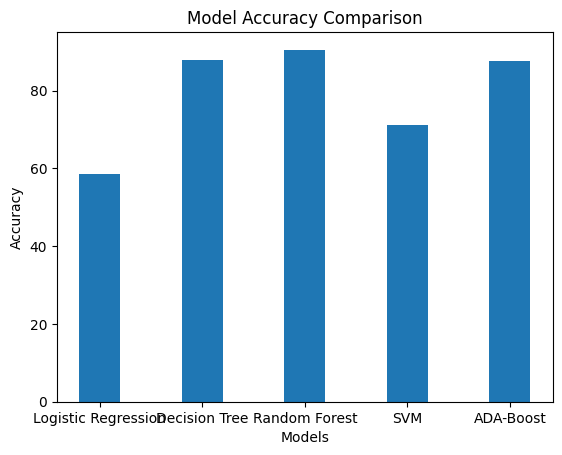

In [ ]:
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM", "ADA-Boost"]
accuracies = [acc_log, acc_dt, acc_clf2, acc_svm, acc_boost]

plt.figure()
plt.bar(model_names, accuracies, width=0.4)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
import torch
import numpy as np


In [ ]:
print(x.shape, y.shape)

(2898, 10) (2898,)


In [ ]:

x=x.to_numpy()
X=torch.from_numpy(x).type(torch.float32)

le = LabelEncoder()
y= le.fit_transform(y)

Y=torch.from_numpy(y).type(torch.float32)

In [ ]:
print(X.size(), Y.size())

torch.Size([2898, 10]) torch.Size([2898])


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.75,random_state=1)

In [ ]:
from torch import nn


# Model

In [ ]:
torch.manual_seed(1)
model=nn.Sequential(nn.Linear(in_features=10,out_features=20),
                    nn.LeakyReLU(),
                    nn.Linear(in_features=20,out_features=40),
                    nn.LeakyReLU(),
                    nn.Linear(in_features=40,out_features=80),
                    nn.LeakyReLU(),
                    nn.Linear(in_features=80,out_features=40),
                    nn.ReLU(),
                    nn.Linear(in_features=40,out_features=16),
                    nn.ReLU(),
                    nn.Linear(in_features=16,out_features=6))

In [ ]:
epochs=2000
n_epoch=[]
train_loss=[]
test_loss=[]
loss_fun=nn.CrossEntropyLoss()
opt=torch.optim.Adagrad(params=model.parameters(),lr=0.1)

In [ ]:
for epoch in range(epochs):
  model.train()
  loss_logit=model(X_train)
  loss1=loss_fun(loss_logit,Y_train.long())
  train_loss.append(loss1)
  opt.zero_grad()
  loss1.backward()
  opt.step()

  model.eval()
  with torch.inference_mode():
    loss_logit=model(X_test)
    loss=loss_fun(loss_logit,Y_test.long())
    test_loss.append(loss)
    n_epoch.append(epoch)

  if epoch %100==0:
    print(f"Epoch: {epoch}, Test loss: {loss:.2f}, Train loss: {loss1:.2f}")

Epoch: 0, Test loss: 2.00, Train loss: 1.81
Epoch: 100, Test loss: 0.83, Train loss: 0.79
Epoch: 200, Test loss: 0.53, Train loss: 0.42
Epoch: 300, Test loss: 0.53, Train loss: 0.47
Epoch: 400, Test loss: 0.44, Train loss: 0.23
Epoch: 500, Test loss: 0.42, Train loss: 0.18
Epoch: 600, Test loss: 0.50, Train loss: 0.14
Epoch: 700, Test loss: 0.45, Train loss: 0.14
Epoch: 800, Test loss: 0.50, Train loss: 0.09
Epoch: 900, Test loss: 0.62, Train loss: 0.06
Epoch: 1000, Test loss: 0.74, Train loss: 0.04
Epoch: 1100, Test loss: 0.70, Train loss: 0.07
Epoch: 1200, Test loss: 0.88, Train loss: 0.03
Epoch: 1300, Test loss: 1.00, Train loss: 0.02
Epoch: 1400, Test loss: 1.08, Train loss: 0.01
Epoch: 1500, Test loss: 1.15, Train loss: 0.01
Epoch: 1600, Test loss: 1.20, Train loss: 0.01
Epoch: 1700, Test loss: 1.25, Train loss: 0.01
Epoch: 1800, Test loss: 1.28, Train loss: 0.01
Epoch: 1900, Test loss: 1.31, Train loss: 0.01


/tmp/ipython-input-3034466608.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(n_epoch, np.array(torch.tensor(train_loss).numpy()), label='Training Loss')


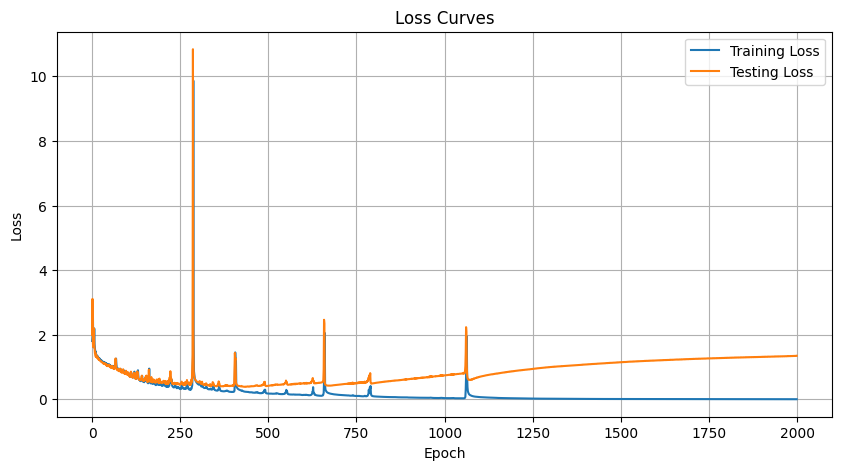

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(n_epoch, np.array(torch.tensor(train_loss).numpy()), label='Training Loss')
plt.plot(n_epoch, np.array(torch.tensor(test_loss).numpy()), label='Testing Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

In [ ]:
with torch.inference_mode():

    test_logit=model(X_test)
    pred=test_logit.softmax(dim=1).argmax(dim=1)

In [ ]:
!pip install torchmetrics
from torchmetrics import Accuracy, Precision, Recall, F1Score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 7.3 MB/s eta 0:00:00


In [ ]:
recall= Recall(task="multiclass", num_classes=6)
Acc=Accuracy(task="multiclass", num_classes=6)
precision= Precision(task="multiclass", num_classes=6)


recall.update(pred, Y_test.long())
Acc.update(pred, Y_test.long())
precision.update(pred, Y_test.long())

calculated_recall = recall.compute()
calculated_accuracy = Acc.compute() *100
calculated_precision = precision.compute()

print(f"Recall: {calculated_recall*100:.2f}%")
print(f"Accuracy: {calculated_accuracy:.2f}%")
print(f"Precision: {calculated_precision*100:.2f}%")

Recall: 89.38%
Accuracy: 89.38%
Precision: 89.38%


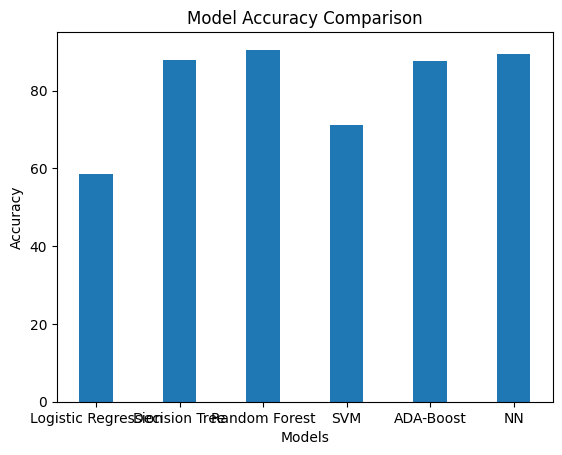

In [ ]:
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM", "ADA-Boost", "NN"]
accuracies = [acc_log, acc_dt, acc_clf2, acc_svm, acc_boost, calculated_accuracy]

plt.figure()
plt.bar(model_names, accuracies, width=0.4)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()